Harika, **PCA bölümünü tamamlaman** gerçekten çok önemli bir adımdı! Şimdi sırada **LDA (Linear Discriminant Analysis)** var ve bu, özellikle **sınıflandırma problemleri** için PCA'dan bile daha güçlü olabiliyor.

Aşağıda sana **videoya başlamadan önce temel LDA mantığını**, **PCA ile farklarını**, **nerede ve nasıl işe yaradığını** sade ve örnekli şekilde anlatacağım:

---

## 🧠 LDA Nedir?

> **Linear Discriminant Analysis (Doğrusal Ayırt Edici Analiz)**, denetimli bir boyut indirgeme tekniğidir.
> Amaç: **Sınıfları birbirinden en iyi ayıracak yeni eksenleri (linear discriminants) bulmaktır.**

---

## 🎯 PCA vs LDA: En Temel Fark

| Özellik      | PCA                                  | LDA                                              |
| ------------ | ------------------------------------ | ------------------------------------------------ |
| Öğrenme türü | **Unsupervised** (etiket gerekmez)   | **Supervised** (etiket gerekir)                  |
| Amaç         | Varyansı maksimize eden eksen bulma  | Sınıflar arası ayrımı maksimize eden eksen bulma |
| Bilgi        | Sadece X (özellikler)                | Hem X hem y (etiketler)                          |
| Hedefi       | Bilgi kaybını azaltarak sadeleştirme | Sınıflar daha iyi ayrılsın                       |

**Örnek:**

* PCA: Genel yapıyı korur, etiket yokmuş gibi davranır.
* LDA: "Ben bu sınıfları daha iyi nasıl ayırırım?" der.

---

## 📌 LDA Ne İşe Yarar?

1. 🔹 **Sınıflandırma problemlerinde doğruluğu artırabilir.**

   * LDA → ardından SVM, Logistic Regression, KNN, Naive Bayes gibi algoritmalarla yüksek başarı sağlar.

2. 🔹 **Yüksek boyutlu verilerde boyutu azaltıp sınıf ayrımını koruyabilir.**

   * Görselleştirme: 100 boyutlu veriyi 2 boyuta indir ama sınıf ayrımı bozulmasın.

3. 🔹 **Karmaşık verilerde daha net sınıf ayrımı sağlar.**

   * Özellikle **sınıflar birbirine yakınsa** ve ayırt edilmesi zorsa, LDA çok faydalı.

---

## 📈 LDA'nın İç Mantığı Nedir?

LDA şunu yapar:

> 🔹 **Sınıflar arası uzaklığı** maksimize eder
> 🔹 **Sınıf içi varyansı** minimize eder

Yani, **sınıfları birbirinden uzaklaştırırken**, **her bir sınıfı kendi içinde kompakt tutar.**

---

## 📊 LDA Sonrası Kaç Boyuta İndirebilirim?

Veride **C sınıf varsa**, LDA en fazla **C - 1** boyuta indirebilir.

**Örnek:**

* 3 sınıf varsa → En fazla 2 lineer diskriminant üretir.
* 2 sınıf varsa → Sadece 1 boyut!

---

## 💡 Ne Zaman LDA Kullanmalısın?

| Durum                                 | LDA Kullanılır mı?        |
| ------------------------------------- | ------------------------- |
| Etiketli sınıflandırma problemi varsa | ✅                         |
| Sınıf ayrımı zor ise                  | ✅                         |
| Görselleştirme yapmak istiyorsan      | ✅                         |
| Etiket yoksa                          | ❌ (PCA kullan)            |
| Veriler lineer değilse                | ⚠️ Kernel LDA gerekebilir |

---

## 🤖 LDA Sonrası Kullanılan Algoritmalar

LDA'dan sonra aşağıdaki sınıflayıcılar çok iyi çalışır:

* Logistic Regression
* SVM
* KNN
* Naive Bayes
* Decision Tree / Random Forest

---

## 🎨 Görsel Fikirle Kafanda Canlansın

Diyelim ki elinde 3 sınıf var ve veri 100 boyutlu. LDA bu sınıfları **C-1 = 2** boyuta indirir ama indirilen boyutlar **sınıf ayrımını maksimumlaştırır**.

> PCA 2D’ye indirir ama sadece varyansa göre.
> LDA 2D’ye indirir ama sınıf ayrımını önceler.

---

## ✅ Özetle:

* LDA, **etiketli verilerde sınıf ayrımını koruyarak boyut indirger**.
* Sınıflandırma modelleri öncesinde güçlü bir ön işleme adımıdır.
* PCA gibi sadece sadeleştirme değil, **ayrıştırma (discrimination)** hedefi vardır.
* Görselleştirme, doğruluk artırma ve eğitim süresini kısaltma gibi avantajlar sunar.

---

İstersen eğitim videosundan sonra gerçek bir Python örneğini de birlikte çalışabiliriz.

Hazırsan şimdi LDA videosuna geçebiliriz. Bitince bana haber ver, kafanda kalan soruları birlikte çözeriz.


## Importing the libraries

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [6]:
dataset = pd.read_csv('Wine.csv')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

## Splitting the dataset into the Training set and Test set

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

## Feature Scaling

In [8]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## Applying LDA

In [9]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
lda = LDA(n_components = 2)
X_train = lda.fit_transform(X_train, y_train) #dikkat edersen etiketi de alıyor
X_test = lda.transform(X_test)

## Training the Logistic Regression model on the Training set

In [10]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state = 0)
classifier.fit(X_train, y_train)

LogisticRegression(random_state=0)

## Making the Confusion Matrix

In [11]:
from sklearn.metrics import confusion_matrix, accuracy_score
y_pred = classifier.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[14  0  0]
 [ 0 16  0]
 [ 0  0  6]]


1.0

## Visualising the Training set results

C:\Users\523579\AppData\Local\Temp\ipykernel_18348\253029307.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


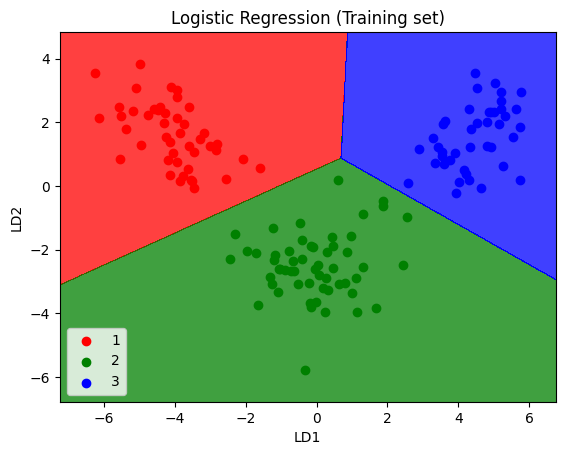

In [12]:
from matplotlib.colors import ListedColormap
X_set, y_set = X_train, y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))
plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green', 'blue')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = ListedColormap(('red', 'green', 'blue'))(i), label = j)
plt.title('Logistic Regression (Training set)')
plt.xlabel('LD1')
plt.ylabel('LD2')
plt.legend()
plt.show()

C:\Users\523579\AppData\Local\Temp\ipykernel_18348\464335527.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


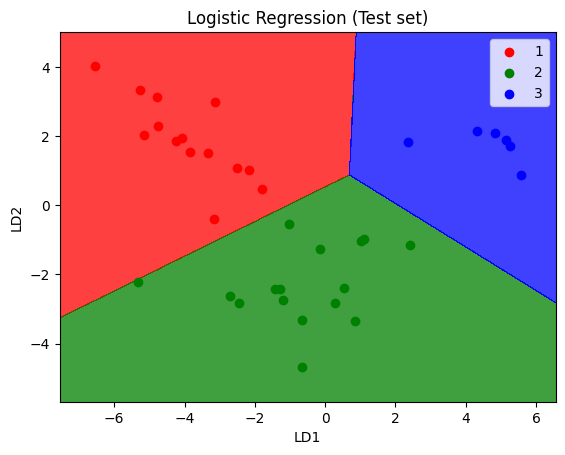

In [13]:
from matplotlib.colors import ListedColormap
X_set, y_set = X_test, y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))
plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green', 'blue')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = ListedColormap(('red', 'green', 'blue'))(i), label = j)
plt.title('Logistic Regression (Test set)')
plt.xlabel('LD1')
plt.ylabel('LD2')
plt.legend()
plt.show()